# Exploratory Data Analysis (EDA) on FNC-1 Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud
from transformers import RobertaTokenizer, XLNetTokenizer
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


d:\SEMESTER 6 - Non Drive\Text Mining\AOL_TextMining_FakeNewsDetection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset Overview


In [3]:
df = pd.read_csv('./data/train/train.csv')

print("Shape of dataset:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nData Types:\n", df.dtypes)
print("\nFeature Names:", list(df.columns))

df.head()


Shape of dataset: (49972, 4)
Number of rows: 49972
Number of columns: 4

Data Types:
 Body ID         int64
articleBody    object
Headline       object
Stance         object
dtype: object

Feature Names: ['Body ID', 'articleBody', 'Headline', 'Stance']


,Body ID,articleBody,Headline,Stance
0,0,A small meteorite crashed into a wooded area i...,"Soldier shot, Parliament locked down after gun...",unrelated
1,0,A small meteorite crashed into a wooded area i...,Tourist dubbed ‘Spider Man’ after spider burro...,unrelated
2,0,A small meteorite crashed into a wooded area i...,Luke Somers 'killed in failed rescue attempt i...,unrelated
3,0,A small meteorite crashed into a wooded area i...,BREAKING: Soldier shot at War Memorial in Ottawa,unrelated
4,0,A small meteorite crashed into a wooded area i...,Giant 8ft 9in catfish weighing 19 stone caught...,unrelated


## Analisis Data Null


,Missing Values,Percentage (%)
Body ID,0,0.0
articleBody,0,0.0
Headline,0,0.0
Stance,0,0.0


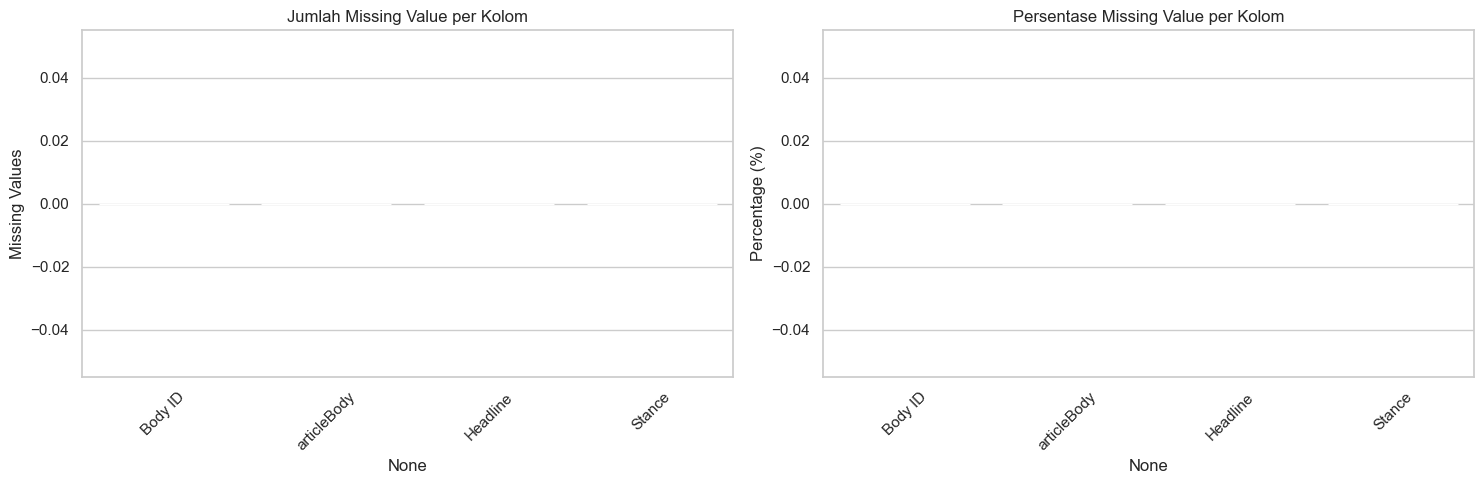

In [4]:
# Missing value per kolom dan persentase
null_counts = df.isnull().sum()
null_percentages = 100 * null_counts / len(df)
null_df = pd.DataFrame({'Missing Values': null_counts, 'Percentage (%)': null_percentages})
display(null_df)

# Visualisasi: Barplot jumlah & persentase missing value
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=null_df.index, y=null_df['Missing Values'], ax=axes[0], palette='Reds')
axes[0].set_title('Jumlah Missing Value per Kolom')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=null_df.index, y=null_df['Percentage (%)'], ax=axes[1], palette='Reds')
axes[1].set_title('Persentase Missing Value per Kolom')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Kesimpulan**: Tidak terdapat data Null pada dataset ini.


## Analisis Data Duplikat


In [ ]:
# Periksa duplikat
dup_row = df.duplicated().sum()

print("Jumlah data duplikat: ", dup_row)

# Menampilkan contoh data duplikat jika ada
if dup_row > 0:
    print("\nContoh Exact Duplicate Row:")
    display(df[df.duplicated(keep=False)].head(2))

Jumlah data duplikat:  402

Contoh Exact Duplicate Row:


,Body ID,articleBody,Headline,Stance,Headline_Char_Len,Headline_Word_Count,headline_word_count,body_word_count,Body_Char_Len,Body_Word_Count,Combined_Text,RoBERTa_Headline,RoBERTa_Body,RoBERTa_Combined,XLNet_Combined
47,5,(NEWSER) – Wonder how long a Quarter Pounder w...,WHO says reports of suspected Ebola cases in I...,unrelated,60,11,11,238,1360,238,WHO says reports of suspected Ebola cases in I...,11,323,334,372
54,5,(NEWSER) – Wonder how long a Quarter Pounder w...,WHO says reports of suspected Ebola cases in I...,unrelated,60,11,11,238,1360,238,WHO says reports of suspected Ebola cases in I...,11,323,334,372


**Kesimpulan**: Terdapat 402 baris data yang duplikat.

## Analisis Distribusi Label


,Count,Percentage (%)
Stance,,
unrelated,36545,73.130953
discuss,8909,17.827984
agree,3678,7.360122
disagree,840,1.680941


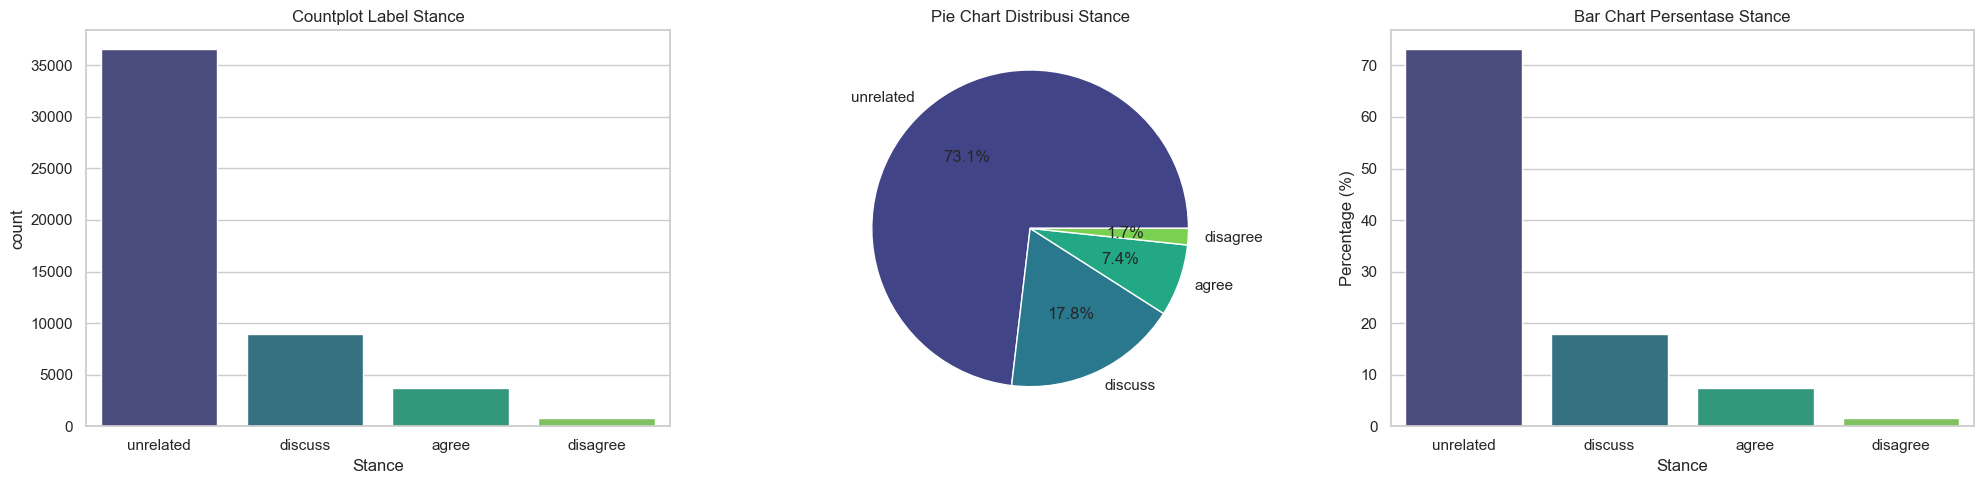

Imbalance Ratio (Max/Min): 43.51


In [6]:
if 'Stance' in df.columns:
    stance_counts = df['Stance'].value_counts()
    stance_percentages = 100 * stance_counts / len(df)
    
    dist_df = pd.DataFrame({'Count': stance_counts, 'Percentage (%)': stance_percentages})
    display(dist_df)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # 1. Countplot
    sns.countplot(data=df, x='Stance', order=stance_counts.index, ax=axes[0], palette='viridis')
    axes[0].set_title('Countplot Label Stance')
    
    # 2. Pie chart
    axes[1].pie(stance_counts, labels=stance_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(stance_counts)))
    axes[1].set_title('Pie Chart Distribusi Stance')
    
    # 3. Bar chart persentase
    sns.barplot(x=dist_df.index, y=dist_df['Percentage (%)'], ax=axes[2], palette='viridis')
    axes[2].set_title('Bar Chart Persentase Stance')
    
    plt.tight_layout()
    plt.show()
    
    # Hitung imbalance ratio (Majority class / Minority class)
    imbalance_ratio = stance_counts.max() / stance_counts.min()
    print(f"Imbalance Ratio (Max/Min): {imbalance_ratio:.2f}")


**Kesimpulan**: Terlihat dengan jelas bahwa dataset ini memiliki ketimpangan jumlah kelas yang sangat besar dimana sebesar 73% berlabel `Unrelated`, 17% berlabel `Discuss`, 7% berlabel `Agree`, dan 1% berlabel `disagree`. Perlu penanganan untuk kelas yang tidak seimbang.

## Analisis Headline


Statistik Panjang Headline:


,mean,median,min,max,std
Headline_Char_Len,69.356860,65.0,9.0,225.0,24.825253
Headline_Word_Count,11.126471,10.0,2.0,40.0,4.201797


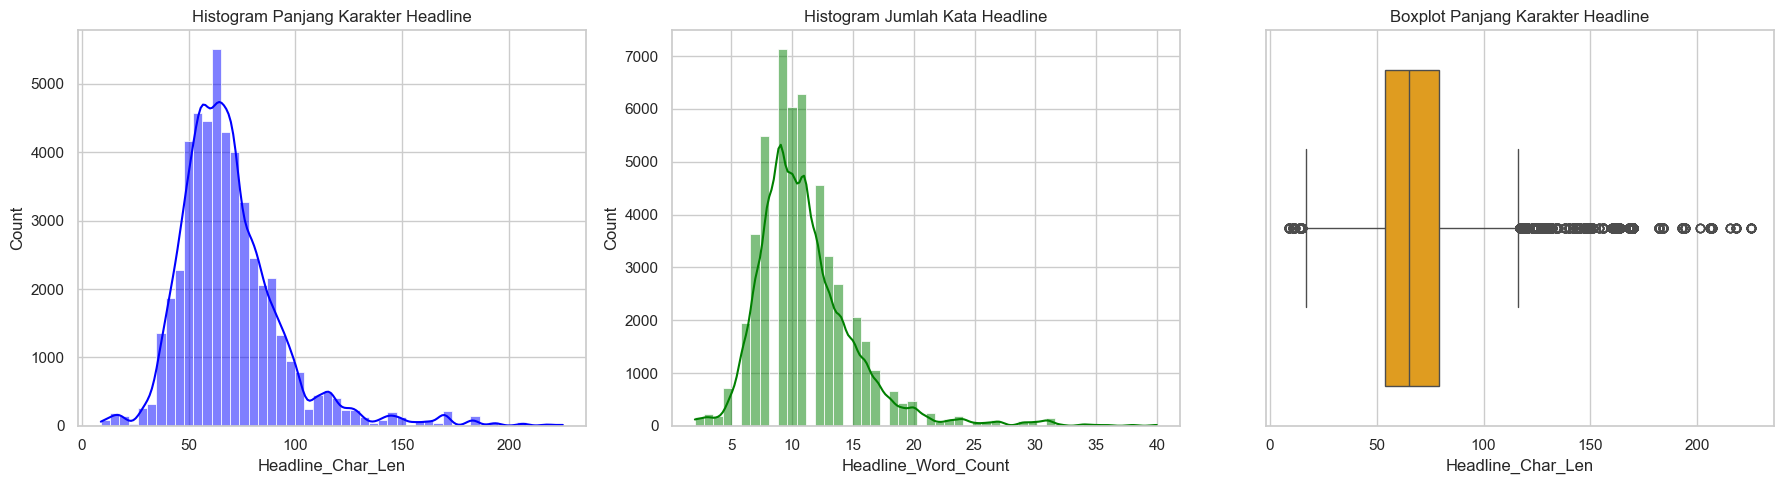

In [7]:
if 'Headline' in df.columns:
    # Mengisi NaN dengan string kosong jika ada
    df['Headline'] = df['Headline'].fillna('')
    
    df['Headline_Char_Len'] = df['Headline'].apply(len)
    df['Headline_Word_Count'] = df['Headline'].apply(lambda x: len(x.split()))
    
    print("Statistik Panjang Headline:")
    display(df[['Headline_Char_Len', 'Headline_Word_Count']].describe().T[['mean', '50%', 'min', 'max', 'std']].rename(columns={'50%':'median'}))
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.histplot(df['Headline_Char_Len'], bins=50, kde=True, ax=axes[0], color='blue')
    axes[0].set_title('Histogram Panjang Karakter Headline')
    
    sns.histplot(df['Headline_Word_Count'], bins=50, kde=True, ax=axes[1], color='green')
    axes[1].set_title('Histogram Jumlah Kata Headline')
    
    sns.boxplot(x=df['Headline_Char_Len'], ax=axes[2], color='orange')
    axes[2].set_title('Boxplot Panjang Karakter Headline')
    
    plt.tight_layout()
    plt.show()


**Kesimpulan**: Terlihat dari grafik di atas bahwa distribusi dari panjang kata `headline` tersebar paling banyak pada angka 10 kata.


## Analisis Article Body

Statistik Panjang Article Body:


,mean,median,min,max,std
Body_Char_Len,2207.547266,1824.0,38.0,27579.0,1676.838550
Body_Word_Count,369.701713,304.0,4.0,4788.0,279.695303


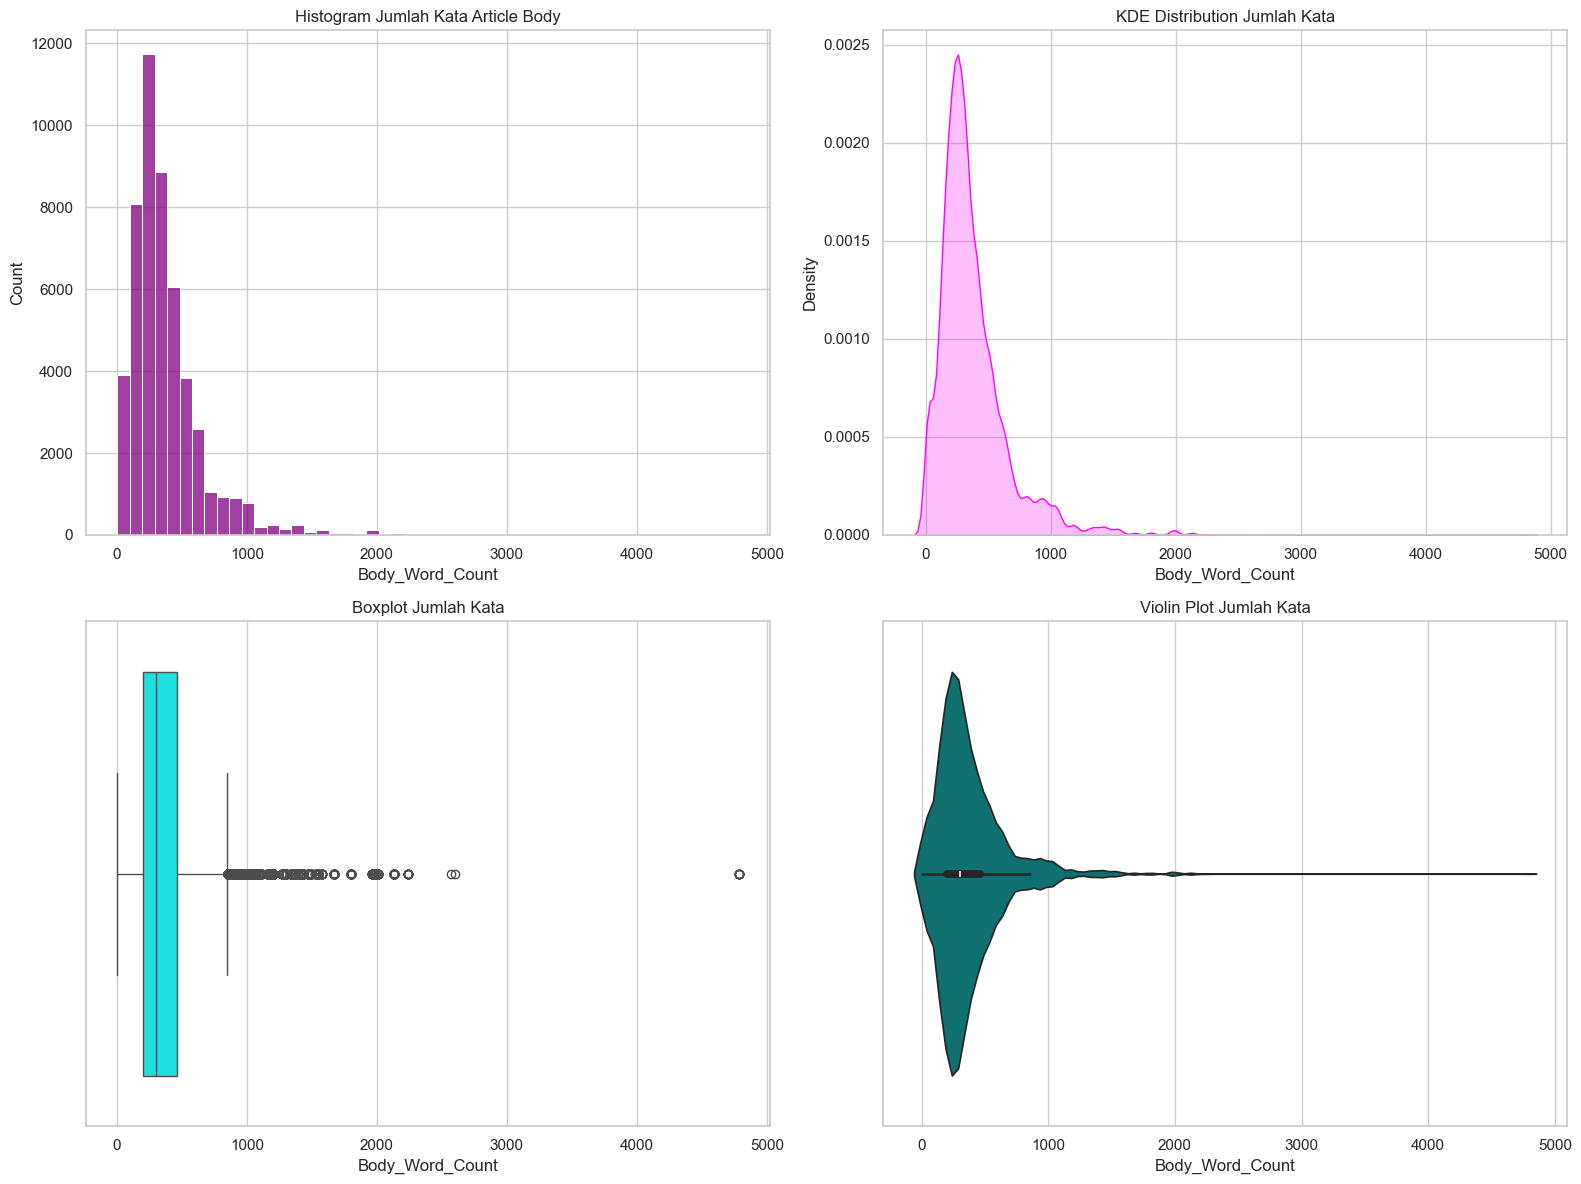

Contoh Outlier (Top 3 artikel terpanjang berdasarkan kata):


,articleBody,Body_Word_Count
23820,Our Retina MacBook Air rumour article brings t...,4788
23821,Our Retina MacBook Air rumour article brings t...,4788
23822,Our Retina MacBook Air rumour article brings t...,4788


In [9]:
if 'articleBody' in df.columns:
    df['articleBody'] = df['articleBody'].fillna('')
    
    df['Body_Char_Len'] = df['articleBody'].apply(len)
    df['Body_Word_Count'] = df['articleBody'].apply(lambda x: len(x.split()))
    
    print("Statistik Panjang Article Body:")
    display(df[['Body_Char_Len', 'Body_Word_Count']].describe().T[['mean', '50%', 'min', 'max', 'std']].rename(columns={'50%':'median'}))
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Histogram
    sns.histplot(df['Body_Word_Count'], bins=50, ax=axes[0,0], color='purple')
    axes[0,0].set_title('Histogram Jumlah Kata Article Body')
    
    # 2. KDE
    sns.kdeplot(df['Body_Word_Count'], fill=True, ax=axes[0,1], color='magenta')
    axes[0,1].set_title('KDE Distribution Jumlah Kata')
    
    # 3. Boxplot
    sns.boxplot(x=df['Body_Word_Count'], ax=axes[1,0], color='cyan')
    axes[1,0].set_title('Boxplot Jumlah Kata')
    
    # 4. Violin
    sns.violinplot(x=df['Body_Word_Count'], ax=axes[1,1], color='teal')
    axes[1,1].set_title('Violin Plot Jumlah Kata')
    
    plt.tight_layout()
    plt.show()
    
    # Highlight outlier article
    print("Contoh Outlier (Top 3 artikel terpanjang berdasarkan kata):")
    display(df.sort_values('Body_Word_Count', ascending=False)[['articleBody', 'Body_Word_Count']].head(3))


**Kesimpulan**: Distribusi panjang teks pada `article body` mayoritas berada di bawah 1.000 kata, dengan konsentrasi tertinggi di kisaran 500 kata. Rata-rata panjang teks sebesar 370 kata semakin memperkuat bukti bahwa sebagian besar artikel berukuran relatif pendek. Oleh karena itu, pemrosesan data ini dapat dilakukan menggunakan model yang lebih ringan dan efisien, khususnya model dengan batas maksimal 512 token.

## Analisis Panjang Kata Headline & Article Body Setiap Kelas

=== Statistik Panjang Kata Headline per Kelas ===


,count,mean,std,min,25%,50%,75%,max
Stance,,,,,,,,
agree,3678.0,11.212344,4.154193,2.0,8.0,10.0,13.0,35.0
disagree,840.0,11.092857,4.100170,3.0,9.0,10.0,13.0,35.0
discuss,8909.0,10.866203,4.134994,2.0,8.0,10.0,12.0,40.0
unrelated,36545.0,11.182050,4.222715,2.0,9.0,10.0,13.0,40.0



=== Statistik Panjang Kata Article Body per Kelas ===


,count,mean,std,min,25%,50%,75%,max
Stance,,,,,,,,
agree,3678.0,344.599511,287.995541,4.0,181.25,277.0,412.0,2243.0
disagree,840.0,371.341667,260.741980,10.0,188.00,304.0,498.0,1523.0
discuss,8909.0,402.536312,337.452212,8.0,198.00,326.0,517.0,4788.0
unrelated,36545.0,364.185908,262.586099,8.0,203.00,304.0,457.0,2129.0


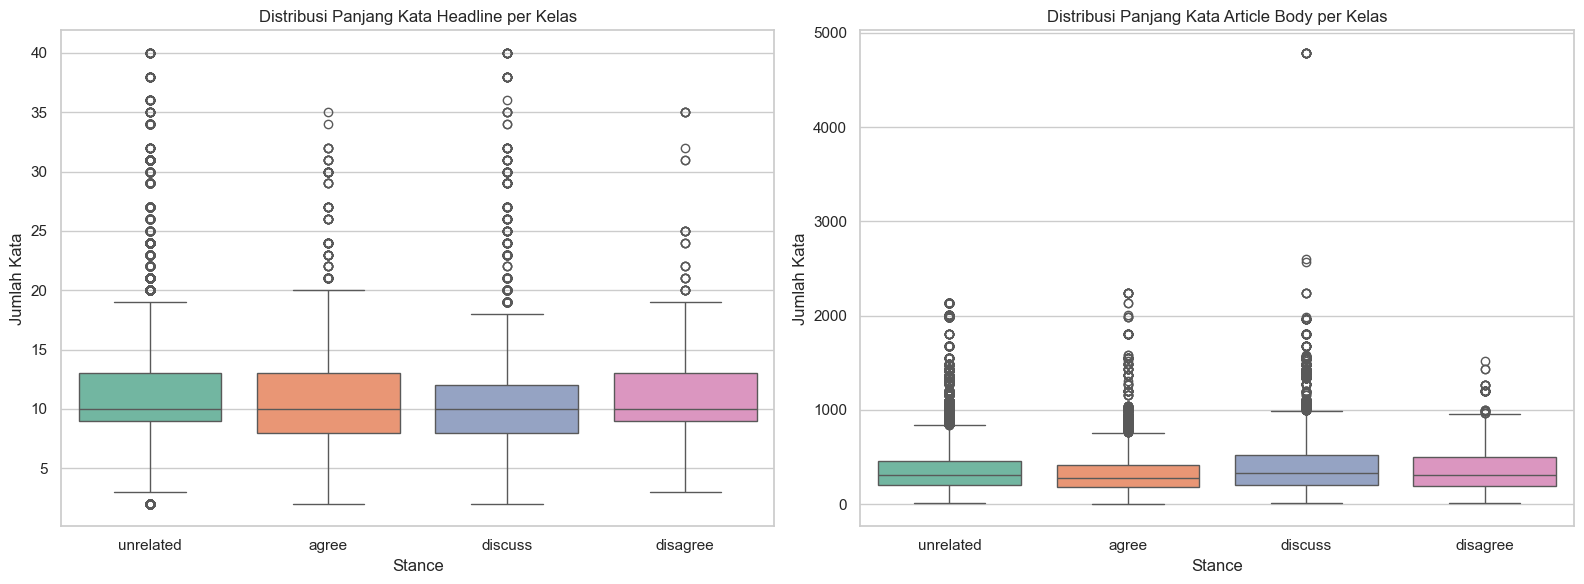

In [10]:
# 1. Menghitung jumlah kata (Word Count) untuk Headline dan Article Body
df['headline_word_count'] = df['Headline'].apply(lambda x: len(str(x).split()))
df['body_word_count'] = df['articleBody'].apply(lambda x: len(str(x).split()))

# 2. Menampilkan Statistik Deskriptif per Kelas
print("=== Statistik Panjang Kata Headline per Kelas ===")
display(df.groupby('Stance')['headline_word_count'].describe())

print("\n=== Statistik Panjang Kata Article Body per Kelas ===")
display(df.groupby('Stance')['body_word_count'].describe())

# 3. Visualisasi Distribusi Panjang Kata menggunakan Boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Stance', y='headline_word_count', ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Panjang Kata Headline per Kelas')
axes[0].set_xlabel('Stance')
axes[0].set_ylabel('Jumlah Kata')

sns.boxplot(data=df, x='Stance', y='body_word_count', ax=axes[1], palette='Set2')
axes[1].set_title('Distribusi Panjang Kata Article Body per Kelas')
axes[1].set_xlabel('Stance')
axes[1].set_ylabel('Jumlah Kata')

plt.tight_layout()
plt.show()

**Kesimpulan**: Data statistik ini semakin mendukung temuan sebelumnya, di mana rata-rata (mean) dan mayoritas distribusi (hingga persentil ke-75) pada setiap kelas konsisten berada di kisaran 500 kata ke bawah. Hal ini menegaskan bahwa kita dapat menggunakan model klasifikasi yang lebih efisien dengan panjang token maksimal di angka 512, tanpa kehilangan banyak konteks informasi

## Token Distribution Analysis


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (647 > 512). Running this sequence through the model will result in indexing errors


,Mean,Median,P90,P95,P99,Max,> 512,> 1024,> 2048,> 4096
RoBERTa Headline,15.662851,15.0,23.0,26.0,36.00,84.0,0.000000,0.000000,0.000000,0.000000
RoBERTa Body,496.355899,407.0,894.0,1240.0,1891.00,6156.0,35.716001,7.656288,0.786440,0.016009
RoBERTa Combined,511.899724,423.0,914.0,1254.0,1904.29,6182.0,37.969263,7.740335,0.790443,0.016009
XLNet Combined,504.455395,417.0,906.0,1218.0,1881.00,6402.0,37.180821,7.504202,0.576323,0.016009


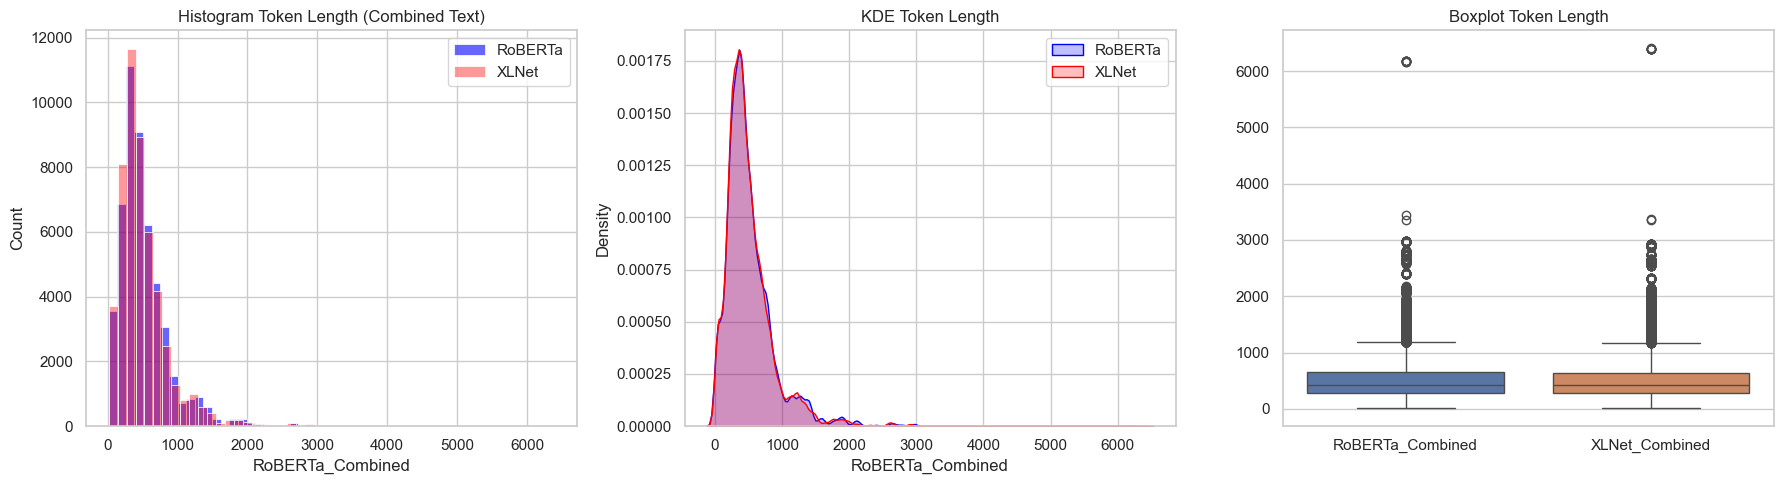

In [20]:
# Meng-load tokenizers
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
xlnet_tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased')

def count_tokens(text, tokenizer):
    # Menggunakan metode yang cepat untuk menghitung token length (tanpa padding/truncation)
    return len(tokenizer.tokenize(text))

sample_df = df

if 'Headline' in sample_df.columns and 'articleBody' in sample_df.columns:
    sample_df['Combined_Text'] = sample_df['Headline'] + " " + sample_df['articleBody']
    
    # RoBERTa
    sample_df['RoBERTa_Headline'] = sample_df['Headline'].apply(lambda x: count_tokens(str(x), roberta_tokenizer))
    sample_df['RoBERTa_Body'] = sample_df['articleBody'].apply(lambda x: count_tokens(str(x), roberta_tokenizer))
    sample_df['RoBERTa_Combined'] = sample_df['Combined_Text'].apply(lambda x: count_tokens(str(x), roberta_tokenizer))
    
    # XLNet
    sample_df['XLNet_Combined'] = sample_df['Combined_Text'].apply(lambda x: count_tokens(str(x), xlnet_tokenizer))
    
    # Buat fungsi ringkasan
    def token_summary(series):
        return {
            'Mean': series.mean(),
            'Median': series.median(),
            'P90': np.percentile(series, 90),
            'P95': np.percentile(series, 95),
            'P99': np.percentile(series, 99),
            'Max': series.max(),
            '> 512': (series > 512).mean() * 100,
            '> 1024': (series > 1024).mean() * 100,
            '> 2048': (series > 2048).mean() * 100,
            '> 4096': (series > 4096).mean() * 100
        }
    
    summary_df = pd.DataFrame({
        'RoBERTa Headline': token_summary(sample_df['RoBERTa_Headline']),
        'RoBERTa Body': token_summary(sample_df['RoBERTa_Body']),
        'RoBERTa Combined': token_summary(sample_df['RoBERTa_Combined']),
        'XLNet Combined': token_summary(sample_df['XLNet_Combined'])
    }).T
    
    display(summary_df)
    
    # Visualisasi
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.histplot(sample_df['RoBERTa_Combined'], bins=50, ax=axes[0], color='blue', alpha=0.6, label='RoBERTa')
    sns.histplot(sample_df['XLNet_Combined'], bins=50, ax=axes[0], color='red', alpha=0.4, label='XLNet')
    axes[0].set_title('Histogram Token Length (Combined Text)')
    axes[0].legend()
    
    sns.kdeplot(sample_df['RoBERTa_Combined'], fill=True, ax=axes[1], color='blue', label='RoBERTa')
    sns.kdeplot(sample_df['XLNet_Combined'], fill=True, ax=axes[1], color='red', label='XLNet')
    axes[1].set_title('KDE Token Length')
    axes[1].legend()
    
    sns.boxplot(data=sample_df[['RoBERTa_Combined', 'XLNet_Combined']], ax=axes[2])
    axes[2].set_title('Boxplot Token Length')
    
    plt.tight_layout()
    plt.show()

**Kesimpulan**: Analisis tokenisasi menggunakan arsitektur BPE menunjukkan bahwa nilai median panjang teks gabungan berada di kisaran 423 token. Walaupun terdapat sekitar 38% data yang melebihi batas 512 token, penggunaan model seperti DeBERTa dengan maksimal 512 token tetap dipertahankan. Hal ini didasari pertimbangan efisiensi komputasi, serta fakta bahwa pada struktur artikel berita, informasi dan konteks krusial umumnya sudah tertuang dengan baik pada bagian headline dan paragraf-paragraf awal teks (inverted pyramid).

## Token Distribution per Label


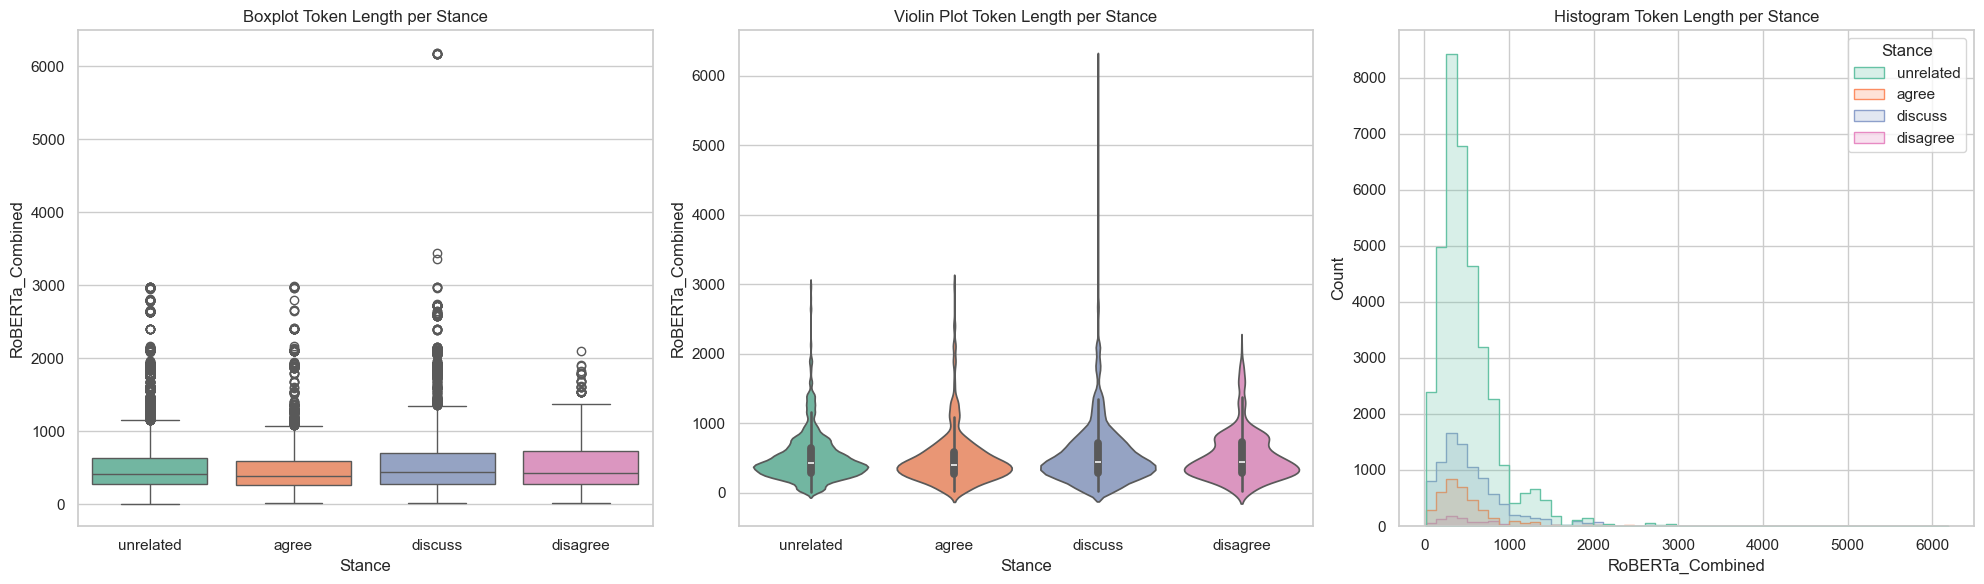

In [13]:
if 'Stance' in sample_df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    sns.boxplot(x='Stance', y='RoBERTa_Combined', data=sample_df, ax=axes[0], palette='Set2')
    axes[0].set_title('Boxplot Token Length per Stance')
    
    sns.violinplot(x='Stance', y='RoBERTa_Combined', data=sample_df, ax=axes[1], palette='Set2')
    axes[1].set_title('Violin Plot Token Length per Stance')
    
    sns.histplot(data=sample_df, x='RoBERTa_Combined', hue='Stance', element='step', common_norm=False, ax=axes[2], palette='Set2', bins=50)
    axes[2].set_title('Histogram Token Length per Stance')
    
    plt.tight_layout()
    plt.show()


Berdasarkan visualisasi distribusi data, mayoritas panjang teks secara konsisten terkonsentrasi di bawah 500 token. Karakteristik ini menjustifikasi pemilihan model Transformer (DeBERTa, RoBERTa, XLNet) dengan batas maksimal 512 token, di mana komputasi menjadi jauh lebih efisien karena meminimalkan informasi penting yang terpotong. Di sisi lain, ukuran teks yang relatif padat ini juga mengoptimalkan pendekatan tradisional (TF-IDF + Logistic Regression) dengan mencegah terbentuknya matriks fitur yang terlalu renggang (sparse), sehingga model dapat mengekstrak pola leksikal dengan lebih fokus dan minim noise.

## Word Frequency Analysis


Memproses teks untuk word frequency...


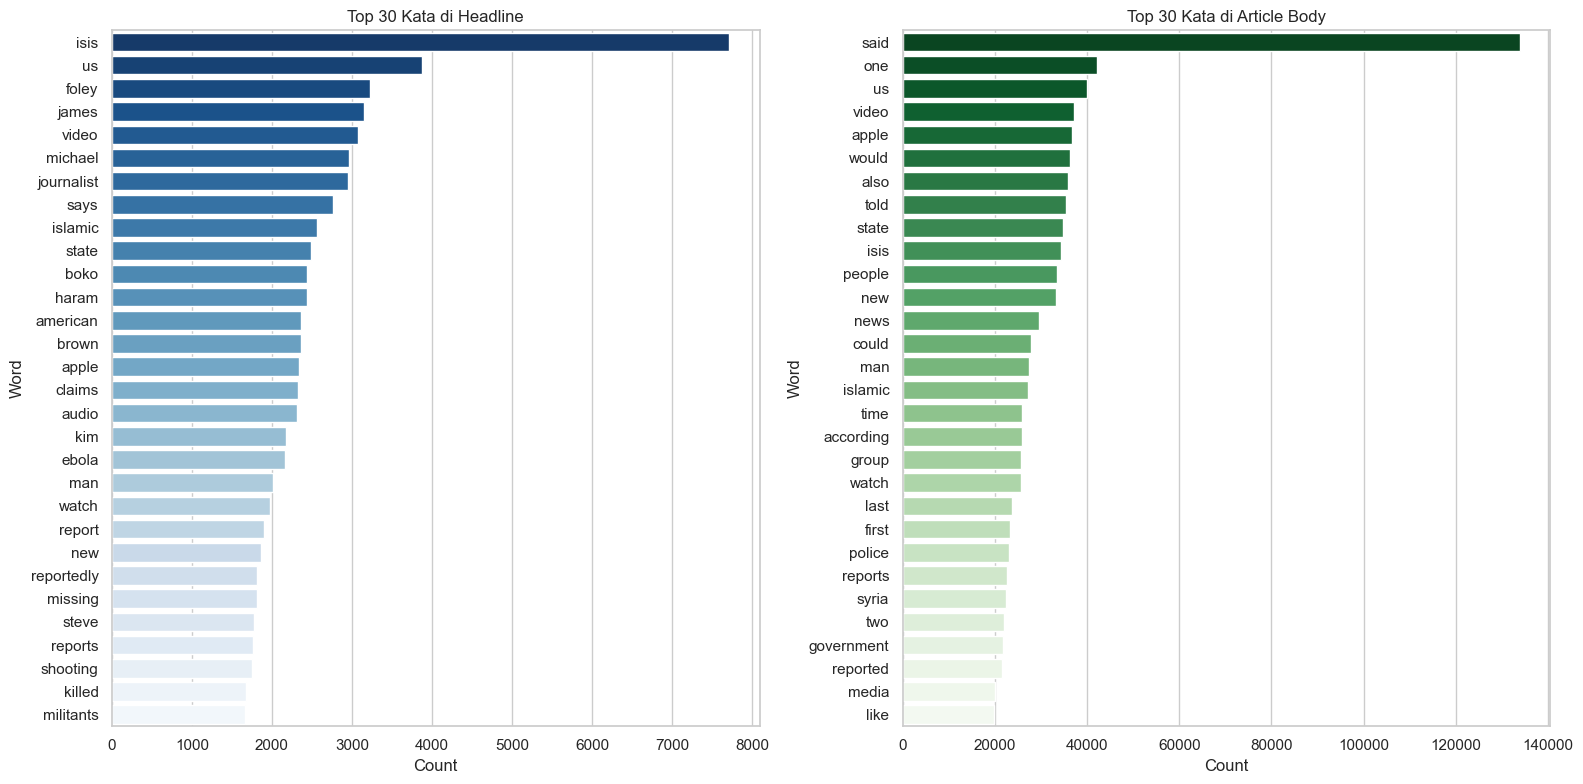

In [14]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase & remove punctuation
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return words

if 'Headline' in df.columns and 'articleBody' in df.columns:
    print("Memproses teks untuk word frequency...")
    freq_df = df
    
    all_headlines_words = []
    freq_df['Headline'].apply(lambda x: all_headlines_words.extend(preprocess_text(x)))
    
    all_body_words = []
    freq_df['articleBody'].apply(lambda x: all_body_words.extend(preprocess_text(x)))
    
    head_counter = Counter(all_headlines_words).most_common(30)
    body_counter = Counter(all_body_words).most_common(30)
    
    head_df = pd.DataFrame(head_counter, columns=['Word', 'Count'])
    body_df = pd.DataFrame(body_counter, columns=['Word', 'Count'])
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    sns.barplot(data=head_df, y='Word', x='Count', ax=axes[0], palette='Blues_r')
    axes[0].set_title('Top 30 Kata di Headline')
    
    sns.barplot(data=body_df, y='Word', x='Count', ax=axes[1], palette='Greens_r')
    axes[1].set_title('Top 30 Kata di Article Body')
    
    plt.tight_layout()
    plt.show()


## WordCloud Analysis


Wordcloud untuk Seluruh Teks:


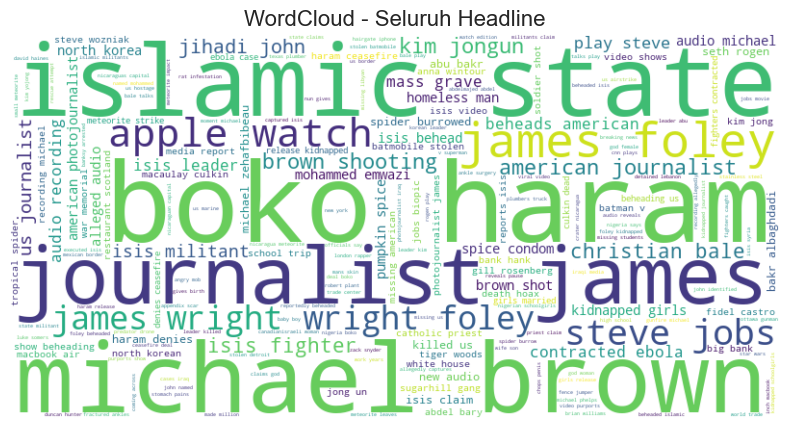

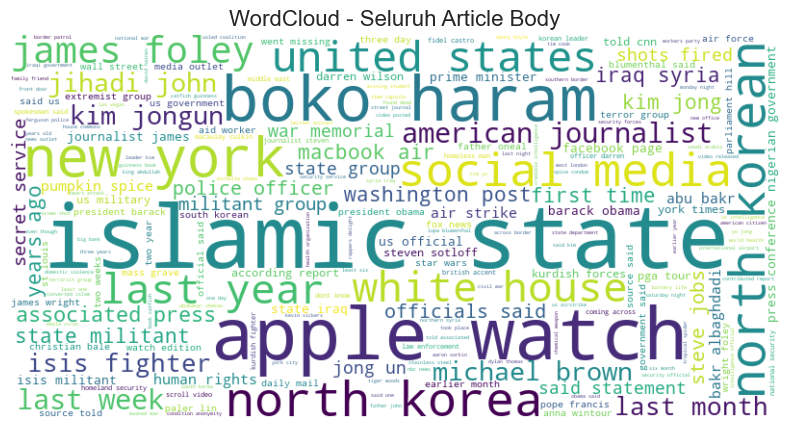

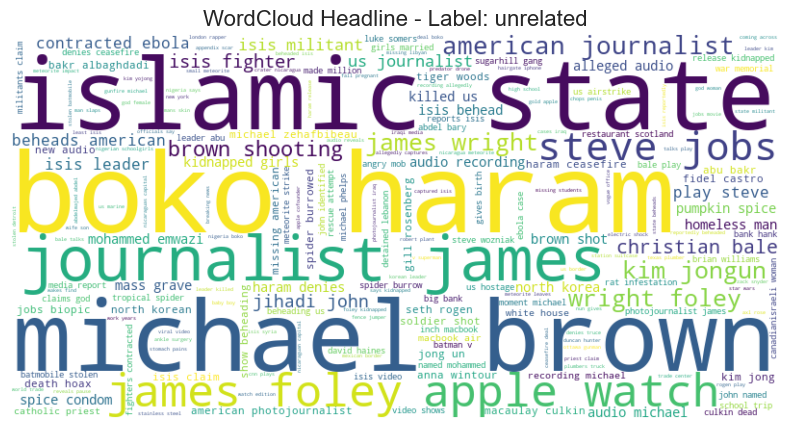

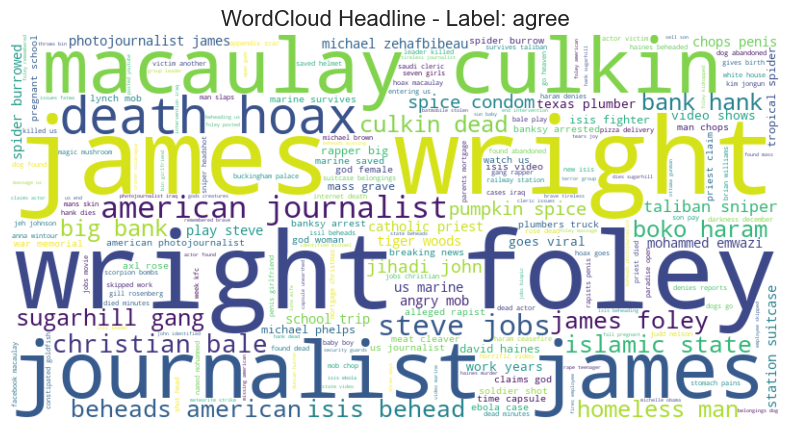

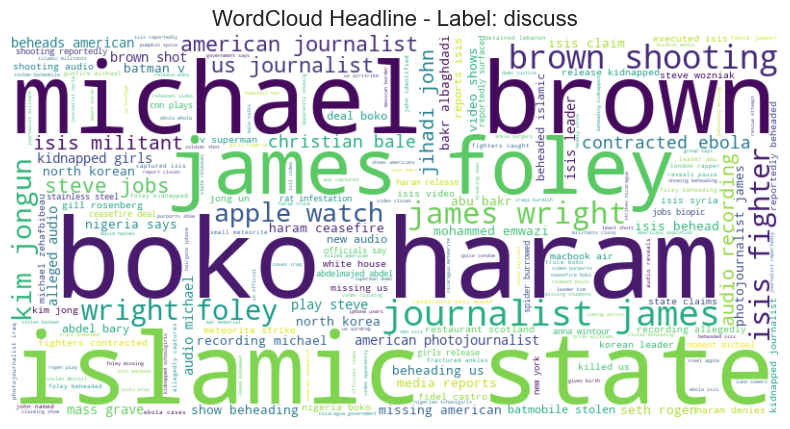

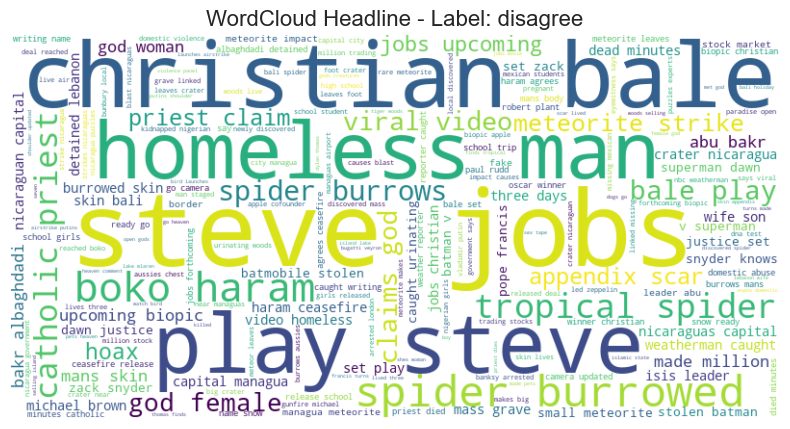

In [15]:
def generate_wordcloud(words_list, title):
    text = ' '.join(words_list)
    if not text.strip(): return
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

if 'Headline' in df.columns and 'articleBody' in df.columns:
    print("Wordcloud untuk Seluruh Teks:")
    generate_wordcloud(all_headlines_words, 'WordCloud - Seluruh Headline')
    generate_wordcloud(all_body_words, 'WordCloud - Seluruh Article Body')
    
    # Wordcloud per label
    if 'Stance' in df.columns:
        stances = df['Stance'].unique()
        for s in stances:
            subset = df[df['Stance'] == s]
            words = []
            subset['Headline'].apply(lambda x: words.extend(preprocess_text(x)))
            generate_wordcloud(words, f'WordCloud Headline - Label: {s}')


## Text Quality Analysis


In [16]:
import re
import pandas as pd

# 1. Definisikan pola regex di luar fungsi agar lebih efisien (hanya di-compile sekali)
url_pattern = re.compile(r'https?://\S+|www\.\S+')
html_pattern = re.compile(r'<.*?>')
email_pattern = re.compile(r'\S+@\S+')
unicode_pattern = re.compile(r'[^\x00-\x7F]+')
multiple_ws_pattern = re.compile(r'\s{2,}')

# 2. Fungsi check_quality
def check_quality(text):
    if not isinstance(text, str):
        return pd.Series([False, False, False, False, False])
        
    has_url = bool(url_pattern.search(text))
    has_html = bool(html_pattern.search(text))
    has_email = bool(email_pattern.search(text))
    has_unicode = bool(unicode_pattern.search(text))
    has_multiple_ws = bool(multiple_ws_pattern.search(text))
    
    return pd.Series([has_url, has_html, has_email, has_unicode, has_multiple_ws])

# 3. Proses datanya
if 'articleBody' in df.columns:
    qual_df = df['articleBody'].apply(check_quality)
    qual_df.columns = ['URL', 'HTML', 'Email', 'UnicodeAneh', 'MultipleWhitespace']
    
    qual_sums = qual_df.sum()
    print(qual_sums)

URL                    1791
HTML                    284
Email                  3389
UnicodeAneh           33002
MultipleWhitespace    45417
dtype: int64


**Kesimpulan**: Teks sangat membutuhkan tahap pembersihan ekstra (preprocessing). Dataset ini memiliki tingkat noise yang tinggi, didominasi oleh masalah spasi ganda (45.417 kasus) dan karakter Unicode aneh/non-ASCII (33.002 kasus). Selain itu, elemen seperti email, URL, dan tag HTML juga harus dibersihkan untuk mencegah terbentuknya token acak (noise vocabulary). Proses pembersihan ini sangat krusial, terutama untuk menjaga kualitas ekstraksi fitur pada model TF-IDF dan mengurangi beban tokenisasi pada model Transformer.